https://www.youtube.com/watch?v=VMj-3S1tku0&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ

https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/micrograd/micrograd_lecture_second_half_roughly.ipynb

In [ ]:
import random
import math

# Objects from 1-playground

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    """
    *args
      data: data variable
      _children: list of previous/parent Value
      _op: what operation created this/child Value
      grad: gradient
      label: label
      backward: an empty function
    """
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.grad = 0.0
    self.label = label
    self._backward = lambda:None

  # Print out a nice looking expression whenever called to print
  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other): # self + other
    other = other if isinstance(other, Value) else Value(other)
    out = Value (self.data + other.data, (self, other), '+')

    # Chain rule for addition
    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out._backward = _backward

    return out

  def __radd__(self, other):
    return self + other

  def __neg__(self): # -self
    return self * - 1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __rsub__(self, other):
    return self - other

  def __mul__(self,other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    # Chain rule for multiplication
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out._backward = _backward

    return out

  def __rmul__(self, other):
    return self * other

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self,), 'exp')

    def _backward():
      # Reminder the derivative of e^x is just e^x
      self.grad += out.data * out.grad
    out._backward = _backward

    return out

  def __pow__(self, other): # x**k
    assert isinstance(other, (int, float)), "only supporting int/float powers"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
      self.grad += other * (self.data ** (other-1)) * out.grad
    out._backward = _backward

    return out

  def __truediv__(self, other): # self / other
    return self * other**-1

  def tanh(self):
    x = self.data
    t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
    out = Value(t, (self,), 'tanh')

    # Chain rule for tanh
    def _backward():
      self.grad = (1 - t**2) * out.grad
    out._backward = _backward

    return out

  # Build topological order
  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v._prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Neuron

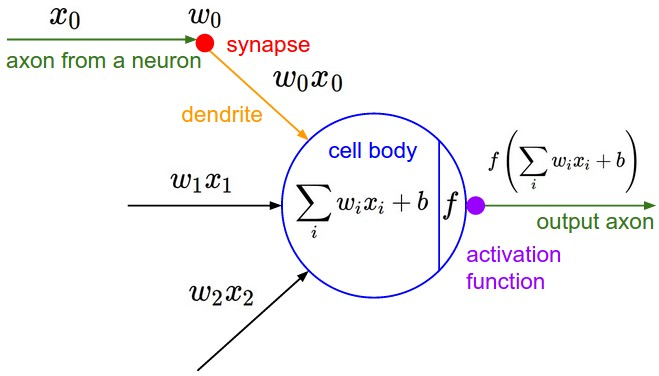

## Neuron
Neuron class defines a single neuron.

In [ ]:
class Neuron:

  def __init__(self, nin):
    """
    @param
      nin = number of input

    self.w = create weight for every inputs that are randomized between -1 and 1
    self.b = create a bias
    """
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b =  Value(random.uniform(-1,1))


  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

Extra explanation on `__call__`
```
def __call__(self, x):
  return 0.0
# w * x + b
# x = [2.0, 3.0]
# n = Neuron(2)
# n(x) << 0.0
```
```
def __call__(self, x):
  # Pairs the weights with x
  zip(self.w, x)
  # print(list(zip(self.w, x)))
  # [(Value(data=-0.4), 2.0), (Value(data=-0.01), 3.0)]
```

## Layer

Each layer has a number of neurons that are not connected to each other but are connected to previous layer.

It is a set of neurons evaluated independently.

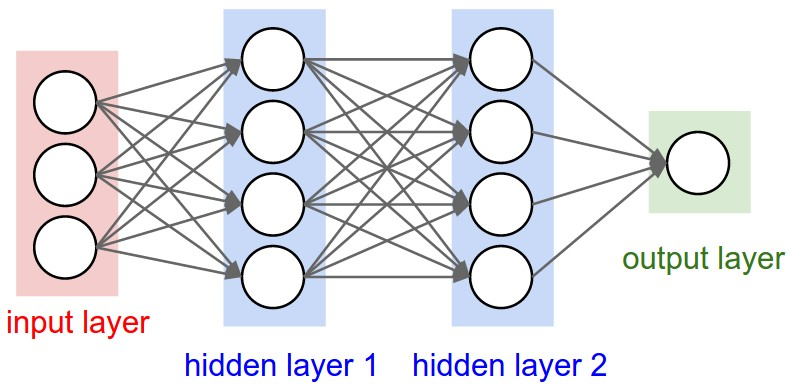

In [ ]:
class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

`nin` = number of input
`nout` = number of neurons in a single layer.

Creating a Layer with 3 2-dimensional Neurons
```
x = [2.0, 3.0]
n = Layer(2, 3)
n(x)

Output:
[Value(data=0.9995420507434842),
 Value(data=-0.9989418418793283),
 Value(data=-0.9982814383308994)]
```

## MLP

nouts = list of n outs; defines the sizes of all layers in the MLP.

In [ ]:
class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

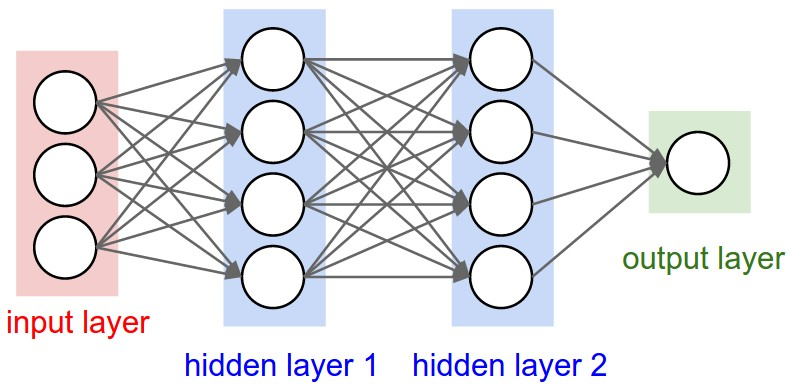

We need input layer with 3 neurons, 2 layers of 4 neurons and 1 output.

In [ ]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(data=0.5495143288038513)

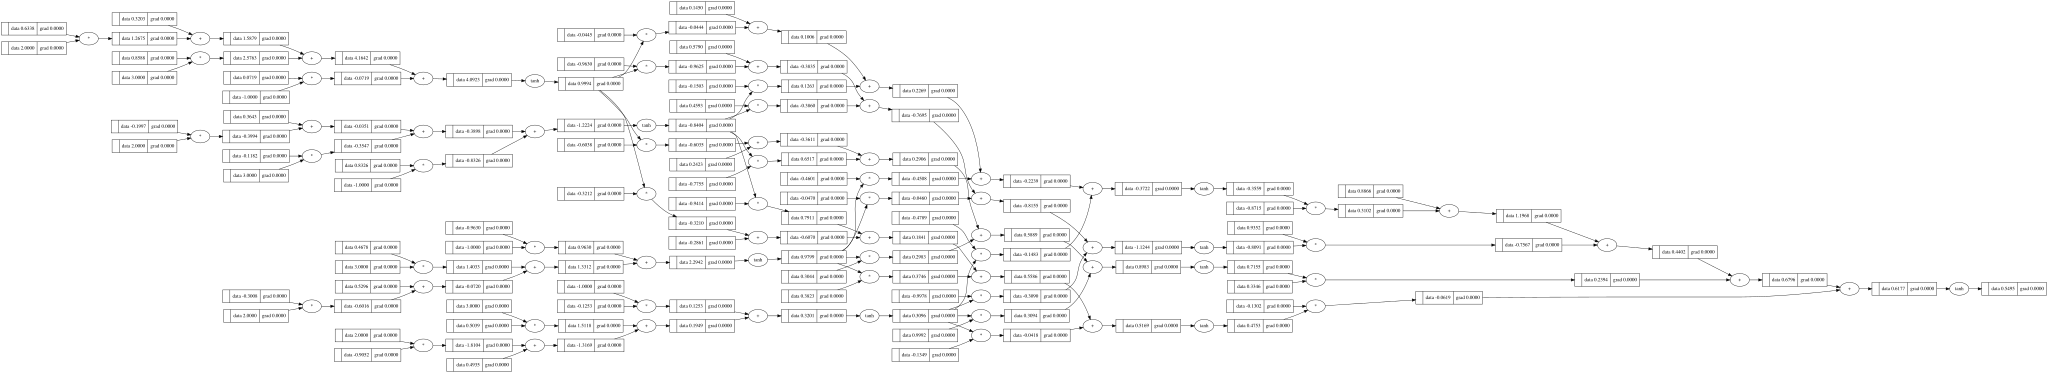

In [ ]:
draw_dot(n(x))

# Example

In [ ]:
# Sample Data
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [ ]:
# First iteration
ypred = [n(x) for x in xs]
ypred

[Value(data=0.5495143288038513),
 Value(data=0.603603289086306),
 Value(data=0.5722562914218778),
 Value(data=0.5740726788271756)]

Calculating the loss is crucial to backpropagation and optimization. The smaller the loss, the closer the prediction is to ground truth. Aim: Lower loss.

`(yout-ygt)**2 to ensure the final product is always positive number`

In [ ]:
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=5.427884777558599)

## Collecting all the parameters of the neural net

In [ ]:
class Neuron:

  def __init__(self, nin):
    """
    @param
      nin = number of input

    self.w = create weight for every inputs that are randomized between -1 and 1
    self.b = create a bias
    """
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b =  Value(random.uniform(-1,1))

  def __call__(self, x):
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out

  # This
  def parameters(self):
    return self.w + [self.b]

From Layer's neurons, get the parameters.

In [ ]:
class Layer:

  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

Similar to Layer's parameters(self)
```
def parameters(self):
    params = []
    for neuron in self.neurons:
      ps = neuron.parameters()
      params.extend(ps)
    return params
```

In [ ]:
class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
n = MLP(3, [4, 4, 1])

## Manual Gradient Descent

Run the following 3 code blocks and watch as the loss drop (as it converges towards better prediction values).

-0.01 is the step_size or learning_rate.

Usually during decay (that is usually practised), start with large step, reduce the step after 75% etc. to ensure convergence and prevent exploding of loss (loss becomes bigger).

In [ ]:
ypred = [n(x) for x in xs]
loss = sum([(yout - ygt)**2 for ygt, yout in zip(ys, ypred)])
loss

Value(data=6.2159154822083815)

In [ ]:
loss.backward()

In [ ]:
for p in n.parameters():
  p.data += -0.01 * p.grad

## With Training loop and defined steps

In [ ]:
steps = 20

for k in range(steps):

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # Note: this is important! Flush your grad!
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad

  print(k, loss.data)

0 5.566949162366331
1 4.349992526709276
2 3.666612346116307
3 3.5835528618682893
4 3.6091017813527997
5 1.867804668326276
6 1.7986457294726628
7 0.1920188407435467
8 0.04576766101502298
9 0.03650209972660476
10 0.030873656282649688
11 0.02696969532179403
12 0.024050200295937664
13 0.021758476671135393
14 0.019897807434541837
15 0.01834918008196332
16 0.017035538516871777
17 0.01590433859856267
18 0.014918260173314185
19 0.014049912153988972


In [ ]:
ypred

[Value(data=0.9431370023756106),
 Value(data=-0.968894187068093),
 Value(data=-0.9321202954525778),
 Value(data=0.9276032751600078)]

Ground truth:

ys = [1.0, -1.0, -1.0, 1.0] # desired targets